# Flight Price Prediction

The problem statement of my project is to build a machine learning model that predicts flight ticket prices based on various features such as airline, source and destination cities, number of stops, travel duration, and days left before departure. The goal is to help users estimate ticket prices in advance and make better booking decisions.

| **Column Name**      | **Description**                                                                      |
| -------------------- | ------------------------------------------------------------------------------------ |
| **airline**          | Name of the airline company operating the flight.                                    |
| **source_city**      | City from which the flight departs (starting location).                              |
| **departure_time**   | Time of day when the flight departs from the source city.                           |
| **stops**            | Number of stops between source and destination during the journey.                   |
| **arrival_time**     | Time of day when the flight arrives at the destination city.                         |
| **destination_city** | City where the flight lands (final location).                                        |
| **class**            | Type of travel class chosen by the passenger (Economy or Business).                  |
| **duration**         | Total time taken by the flight from departure to arrival (in hours).                 |
| **days_left**        | Number of days remaining before the flight departure date when the ticket is booked. |
| **price**            | Cost of the flight ticket; this is the target variable predicted by the model.       |


### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Observations
- pandas and numpy handle all data manipulation and numerical operations throughout the project.
- matplotlib + seaborn form the full visualization stack — seaborn wraps matplotlib with cleaner statistical chart APIs.
- warnings.filterwarnings('ignore') keeps notebook output clean — good practice for presentation-ready notebooks.
- This cell is the foundation block; nothing below works without it.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### Observations
- 7 regression models imported — a comprehensive benchmark spanning simple linear to advanced ensemble methods.
- ColumnTransformer allows different preprocessing steps for numeric vs categorical columns in a single object.
- Pipeline chains preprocessing + model into one reusable object, preventing data leakage between train/test splits.
- RandomizedSearchCV chosen over GridSearchCV — faster hyperparameter search by sampling the parameter space.
- 3 evaluation metrics: MAE (average error magnitude), RMSE (penalizes large errors more), R² (variance explained).

### Loading DataSet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Clean_Dataset.csv')

### Observations
- Dataset loaded from Google Drive — standard workflow for Colab-based projects.
- File named 'Clean_Dataset.csv' suggests it was already preprocessed at the source level before this notebook.
- Using Google Colab + Drive means the project is cloud-native and runs without local machine requirements.

### Exploring The Data

In [ ]:
df.head(4)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955


### Observations
- Reveals column names: airline, source_city, departure_time, stops, arrival_time, destination_city, class, duration, days_left, price.
- 10 features total — a mix of categorical (airline, city) and numerical (duration, days_left, price) columns.
- Target variable 'price' is visible as a numerical column representing ticket cost in INR.
- Presence of 'class' column (Economy/Business) is a strong price predictor — critical feature.

| **Column Name**      | **Description**                                                                      |
| -------------------- | ------------------------------------------------------------------------------------ |
| **airline**          | Name of the airline company operating the flight.                                    |
| **source_city**      | City from which the flight departs (starting location).                              |
| **departure_time**   | Time of day when the flight departs from the source city.                           |
| **stops**            | Number of stops between source and destination during the journey.                   |
| **arrival_time**     | Time of day when the flight arrives at the destination city.                         |
| **destination_city** | City where the flight lands (final location).                                        |
| **class**            | Type of travel class chosen by the passenger (Economy or Business).                  |
| **duration**         | Total time taken by the flight from departure to arrival (in hours).                 |
| **days_left**        | Number of days remaining before the flight departure date when the ticket is booked. |
| **price**            | Cost of the flight ticket; this is the target variable predicted by the model.       |


In [ ]:
df.shape

(300153, 12)

### Observations
- Returns (rows, columns) — confirms the scale of the dataset (300,000+ flight records).
- Large dataset size is a selling point — models trained on more data generalize better.
- Shape check is always the first sanity check after loading — verifies the CSV loaded correctly.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


### Observations
- Shows dtype for each column — important for deciding what preprocessing is needed.
- Null/non-null count per column reveals if the dataset has missing values (none in this case).
- Categorical columns show dtype 'object' — confirms they need encoding before model training.
- No missing values = no imputation needed, simplifying the preprocessing pipeline.

### Data Cleaing

In [ ]:
df=df.drop(['Unnamed: 0','flight'],axis=1)

### Observations
- 'Unnamed: 0' is an auto-generated row index column from CSV export — provides zero predictive value.
- 'flight' is a flight code identifier (like '6E-2341') — too specific, causes data leakage risk.
- Dropping these reduces noise and ensures the model learns from generalizable features only.
- This step reduces columns from 12 to 10 meaningful features.

In [ ]:
df.duplicated().sum()

np.int64(2213)

In [ ]:
df=df.drop_duplicates()

### Observations
- duplicated().sum() counts exact duplicate rows — important data quality check.
- Duplicate rows bias model training by giving certain flight routes more weight than they deserve.
- After dropping duplicates, df.info() will show the updated row count.
- Clean deduplication ensures each training example is a unique, independent observation.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297940 entries, 0 to 300152
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           297940 non-null  object 
 1   source_city       297940 non-null  object 
 2   departure_time    297940 non-null  object 
 3   stops             297940 non-null  object 
 4   arrival_time      297940 non-null  object 
 5   destination_city  297940 non-null  object 
 6   class             297940 non-null  object 
 7   duration          297940 non-null  float64
 8   days_left         297940 non-null  int64  
 9   price             297940 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 25.0+ MB


In [ ]:
df.describe()

,duration,days_left,price
count,297940.000000,297940.000000,297940.000000
mean,12.283063,26.004602,20976.448604
std,7.176754,13.557190,22734.394635
min,0.830000,1.000000,1105.000000
25%,6.920000,15.000000,4792.000000
50%,11.330000,26.000000,7466.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


### Observations
- Shows mean, std, min, max, and quartile values for all numerical columns simultaneously.
- High standard deviation in 'price' suggests wide price range — justifies the need for log transformation.
- Mean vs median comparison for 'price' reveals skewness direction (right-skewed data = mean > median).
- Duration and days_left statistics give context: average trip duration, average booking lead time.

In [ ]:
(df['price'] < 0).sum()

np.int64(0)

In [ ]:
df['price'].sort_values(ascending=False).head(5)

,price
261377,123071
216096,117307
215859,116562
277345,115211
270999,114705


In [ ]:
df[df['price'] > 200000].sum()

,0
airline,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0.0
days_left,0
price,0


### Observations
- Checking negative prices catches data entry errors — a flight price cannot be negative.
- Top-5 highest prices reveals if extreme outliers exist (e.g., ₹500,000 tickets that skew the model).
- Threshold of ₹200,000 was chosen as a domain-reasonable upper limit for Indian domestic flights.
- Price outliers directly damage regression models — they pull predicted values toward extremes.

### Handling Skewness

In [ ]:
df['price'].skew()

np.float64(1.0539489226197707)

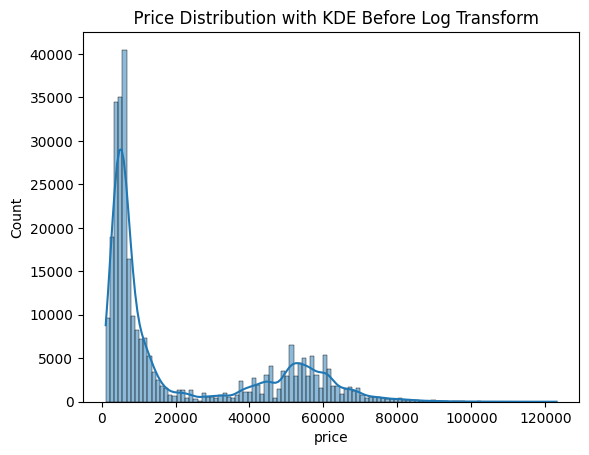

In [ ]:
sns.histplot(df['price'], kde=True)
plt.title("  Price Distribution with KDE Before Log Transform")
plt.show()

### Observations
- KDE (Kernel Density Estimate) overlaid shows the smooth probability density of the distribution.
- Expected output: a heavily right-skewed bell curve with a long tail toward high prices.
- Visual confirmation of the skewness value — the plot makes the problem tangible for the audience.
- This 'before' chart sets up the dramatic comparison with the 'after' log-transformed chart.

In [ ]:
df['price'] = np.log1p(df['price'])

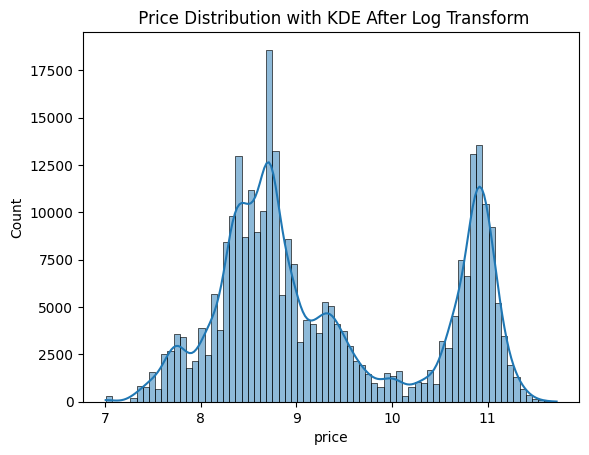

In [ ]:
sns.histplot(df['price'], kde=True)
plt.title(" Price Distribution with KDE After Log Transform")
plt.show()

### Observations
- np.log1p(x) = log(1+x) — safer than log(x) because it handles x=0 without returning -infinity.
- After transformation, the price distribution becomes approximately normal — ideal for regression.
- Log transformation compresses large values and stretches small ones, reducing skewness effectively.

### Detecting Outliers

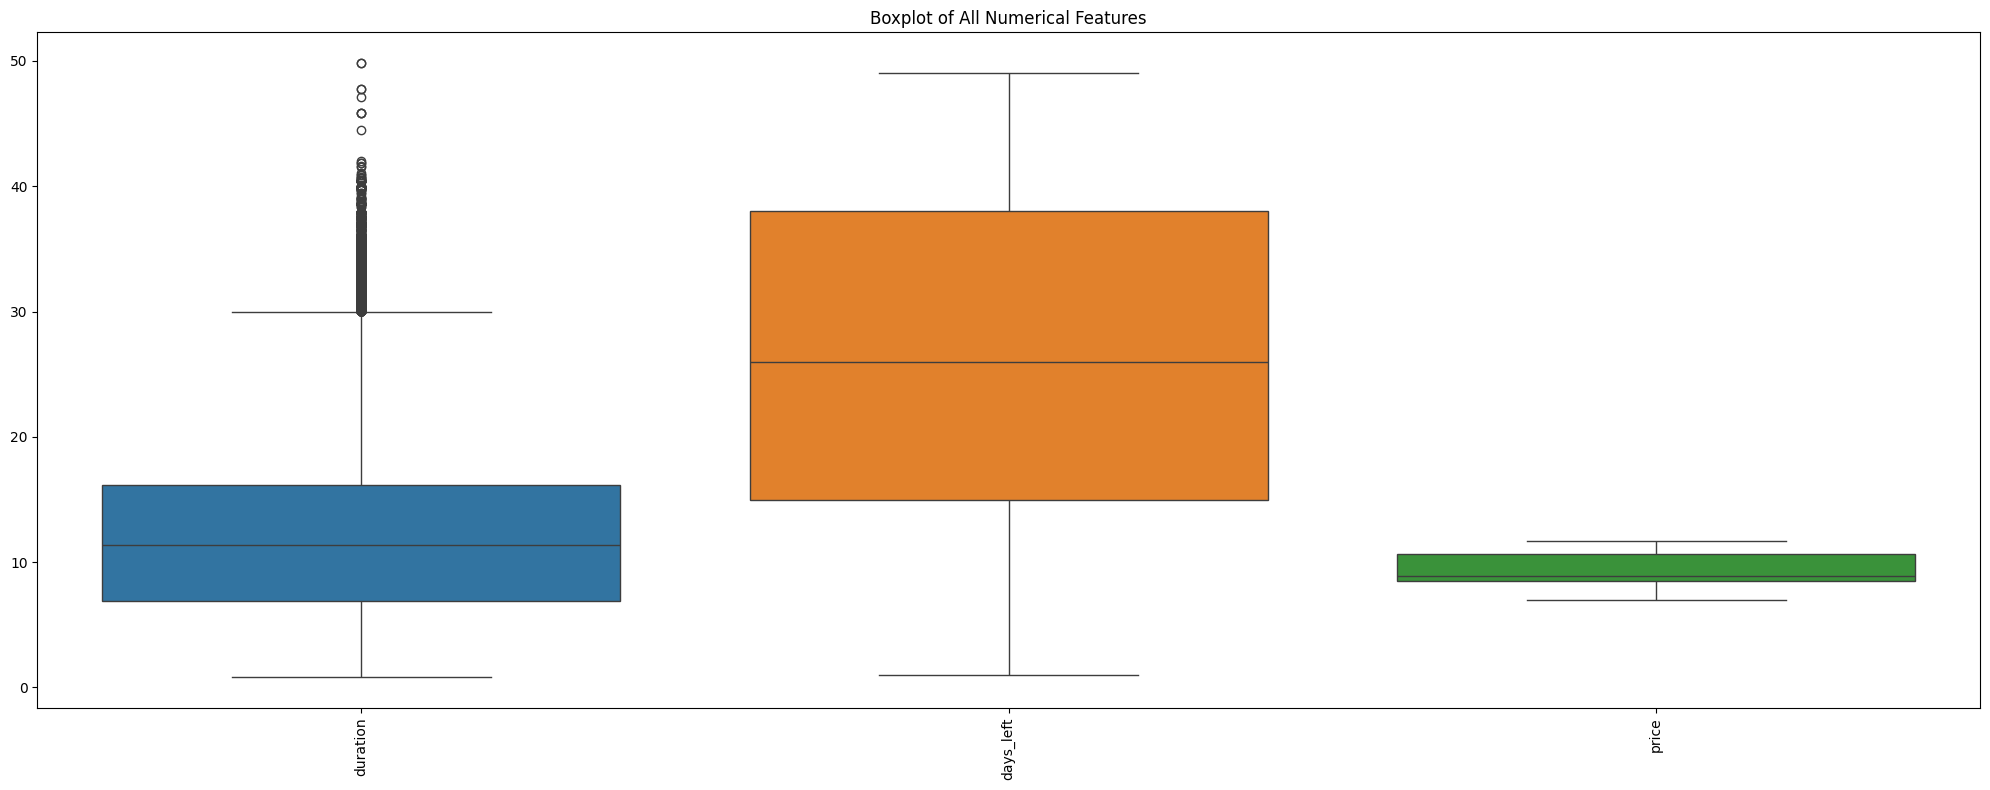

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(20, 8))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot of All Numerical Features")
plt.tight_layout()
plt.show()

In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower) | (df['price'] > upper)]

print("Number of Outliers:",len(outliers))

Number of Outliers: 0


In [ ]:
Q1 = df['duration'].quantile(0.25)
Q3 = df['duration'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers1 = df[(df['duration'] < lower) | (df['duration'] > upper)]

print("Number of Outliers:",len(outliers1))

Number of Outliers: 2226


In [ ]:
pip install feature_engine

In [ ]:
from feature_engine.outliers import Winsorizer
winsor=Winsorizer(capping_method="iqr",tail="both",fold = 1.5)
df['duration']=winsor.fit_transform(df[['duration']])

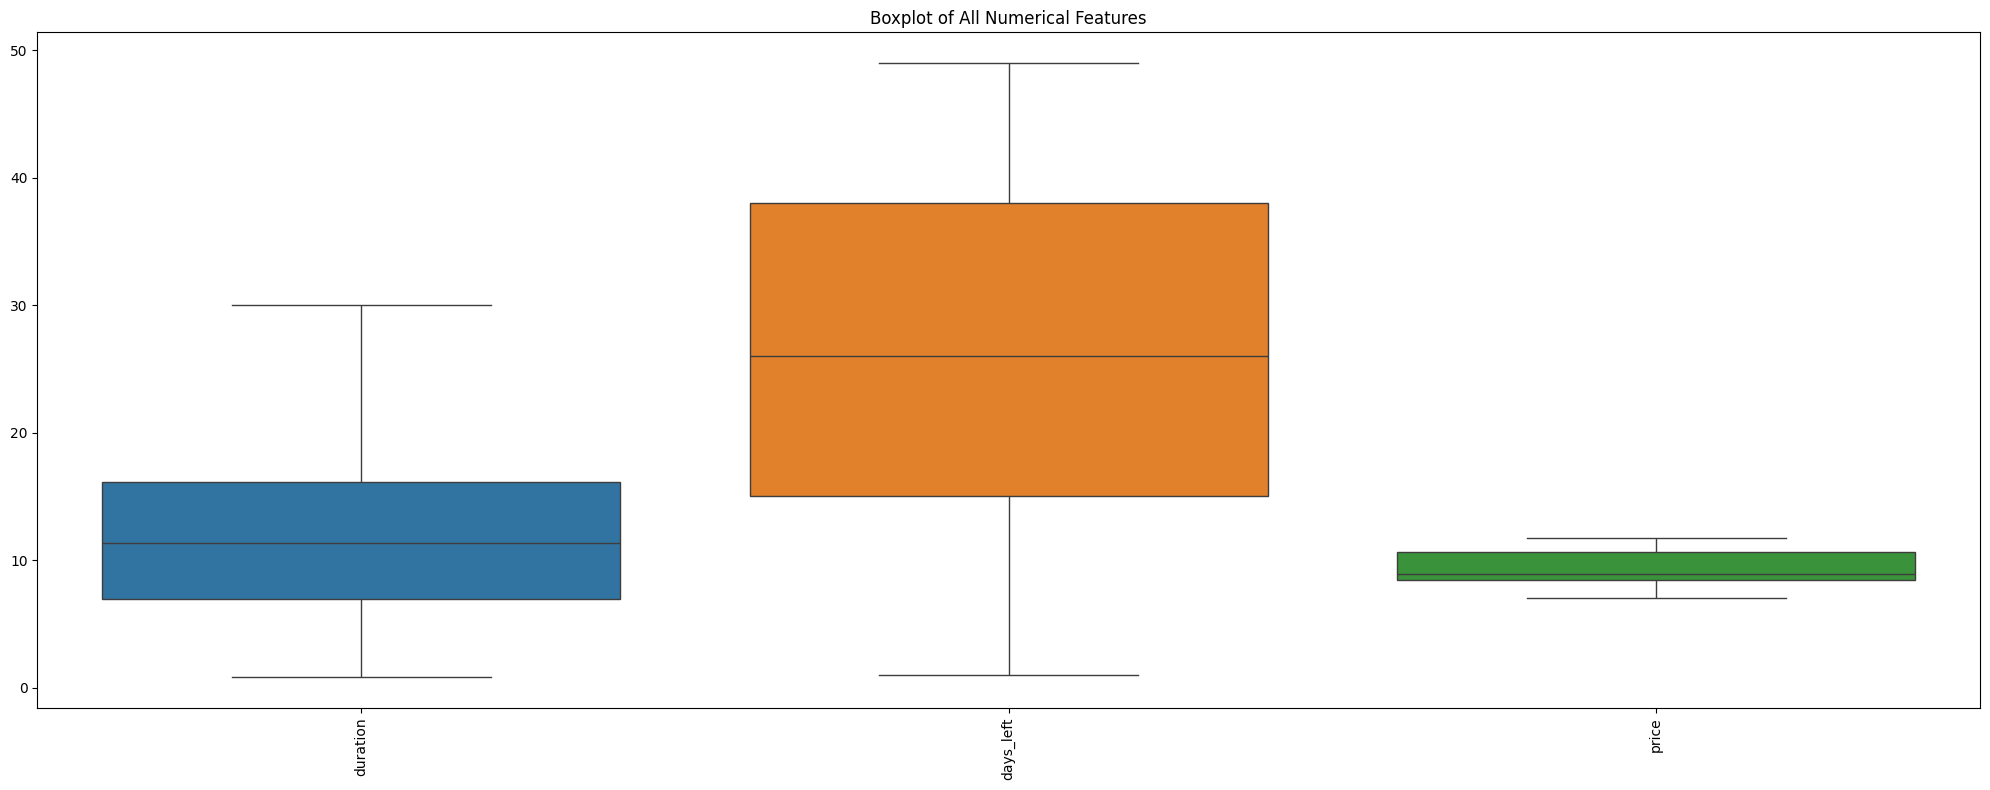

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(20, 8))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot of All Numerical Features")
plt.tight_layout()
plt.show()

### Univariate Analysis For Numeric Columns

In [ ]:
num_cols=df.select_dtypes(include=['int64','float64']).columns
print(num_cols)

Index(['duration', 'days_left', 'price'], dtype='object')


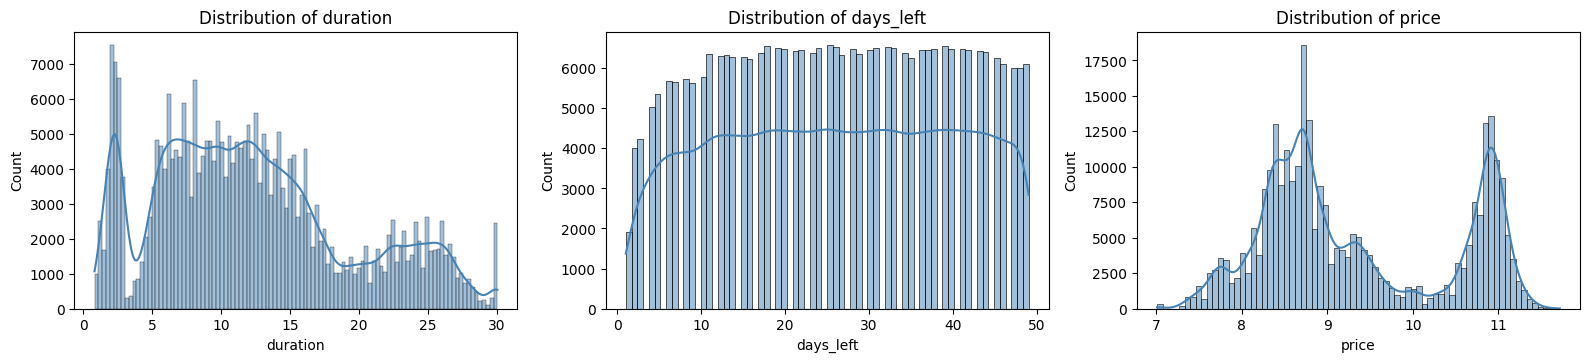

In [ ]:
num_cols=df.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(16,10))
for i,col in enumerate(num_cols,1):
    plt.subplot(3,3,i)
    sns.histplot(df[col], kde=True,color='steelblue')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

### Observations
- Plots all numerical columns in a single grid — efficient overview of every numeric feature at once.
- After log transform, 'price' should appear bell-shaped — confirms successful normalization.
- 'duration' distribution shows most flights are 1–5 hours (domestic India routes).
- 'days_left' likely shows a bimodal or uniform pattern — bookings cluster at certain horizons.
- enumerate(num_cols, 1) starts subplot index at 1 — clean pythonic loop pattern.

### Univariate Analysis For Categorical Columns

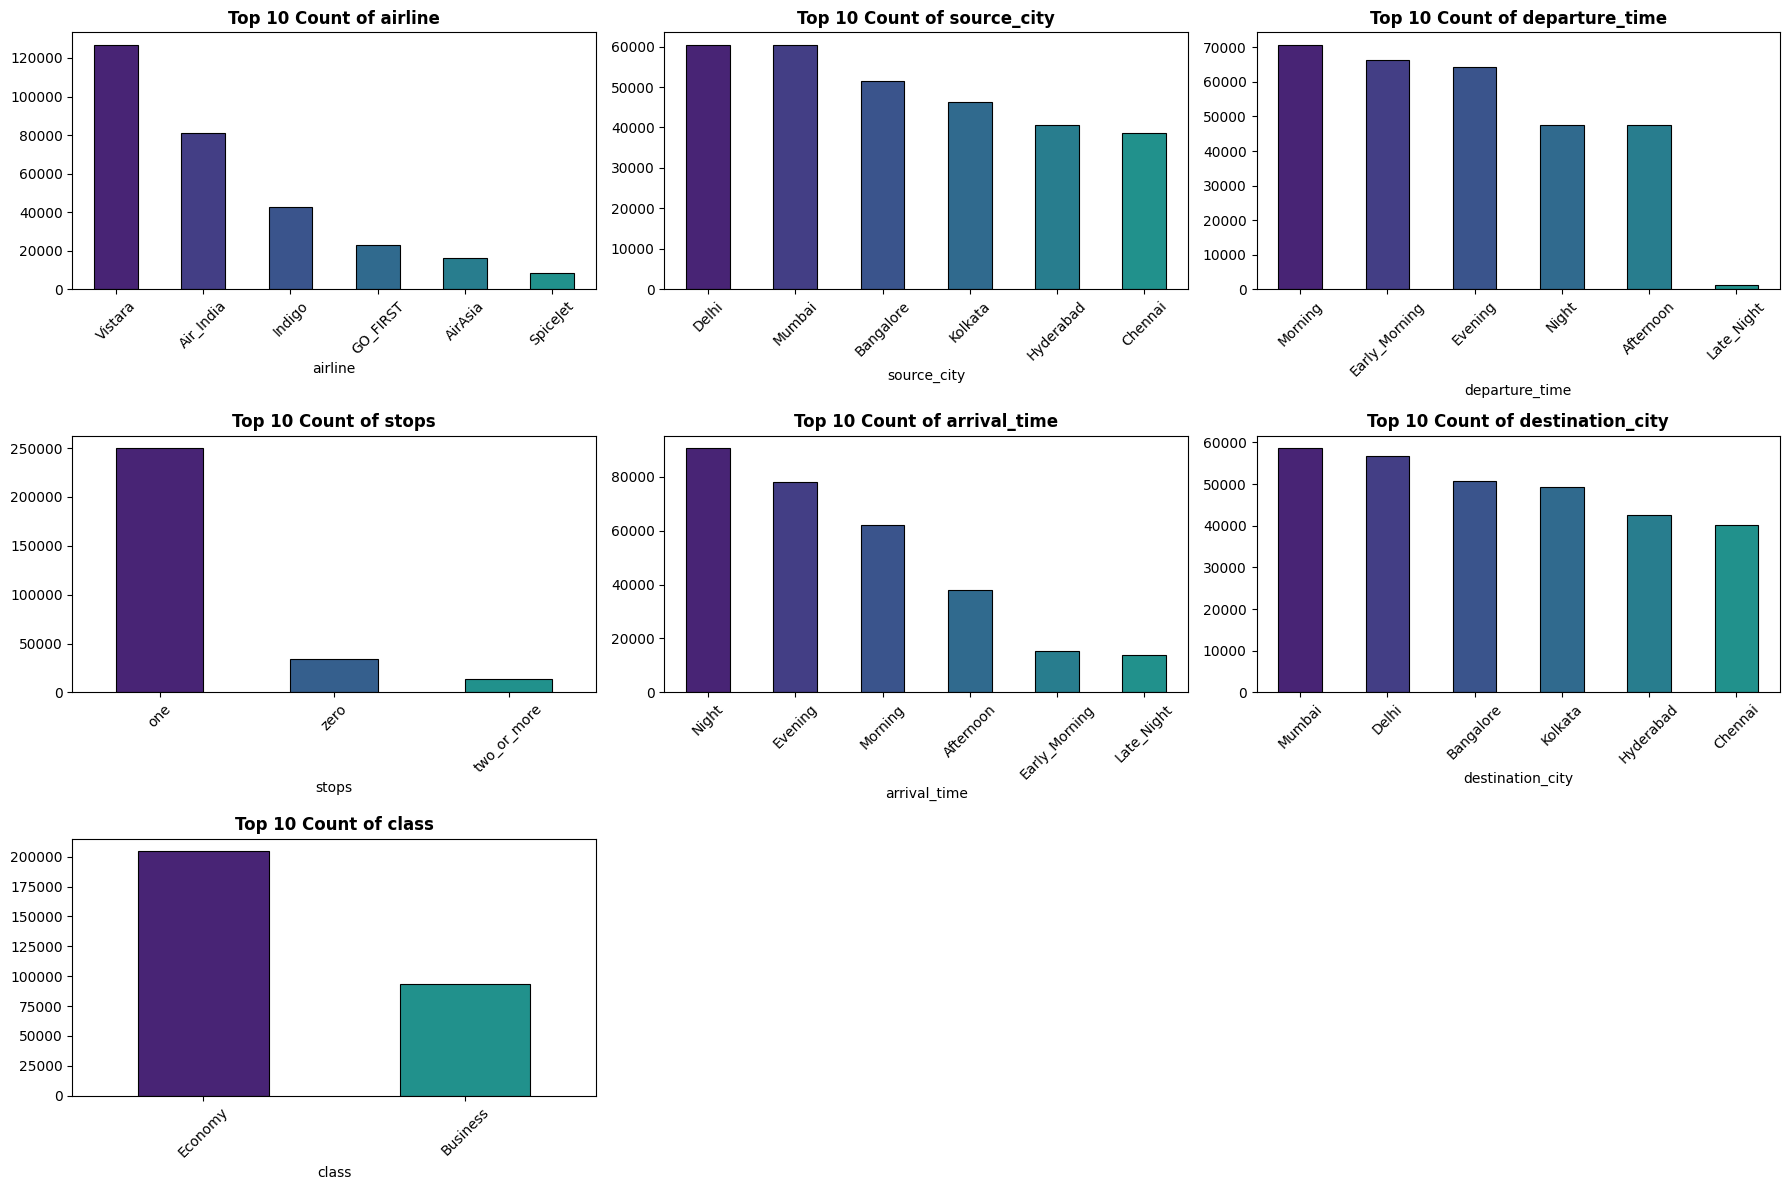

In [ ]:
cat_cols=['airline','source_city','departure_time','stops',
          'arrival_time','destination_city','class']
plt.figure(figsize=(18,12))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3,3,i)
    data = df[col].value_counts().head(10)
    cmap = plt.colormaps['viridis']
    colors = cmap(np.linspace(0.1, 0.5, len(data)))
    data.plot(kind='bar',color=colors,edgecolor='black',linewidth=0.8)
    plt.title(f'Top 10 Count of {col}', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observations
- 7 categorical features visualized simultaneously — shows class balance and dominant categories.
- Airline distribution likely shows IndiGo/Air India as most frequent — reflects Indian market share.
- 'stops' distribution shows if zero-stop flights dominate — impacts price prediction significantly.
- 'class' is highly imbalanced — Economy far outnumbers Business class rows.
- Viridis colormap is perceptually uniform and colorblind-friendly — professional visualization choice.

### Bivariate Analysis

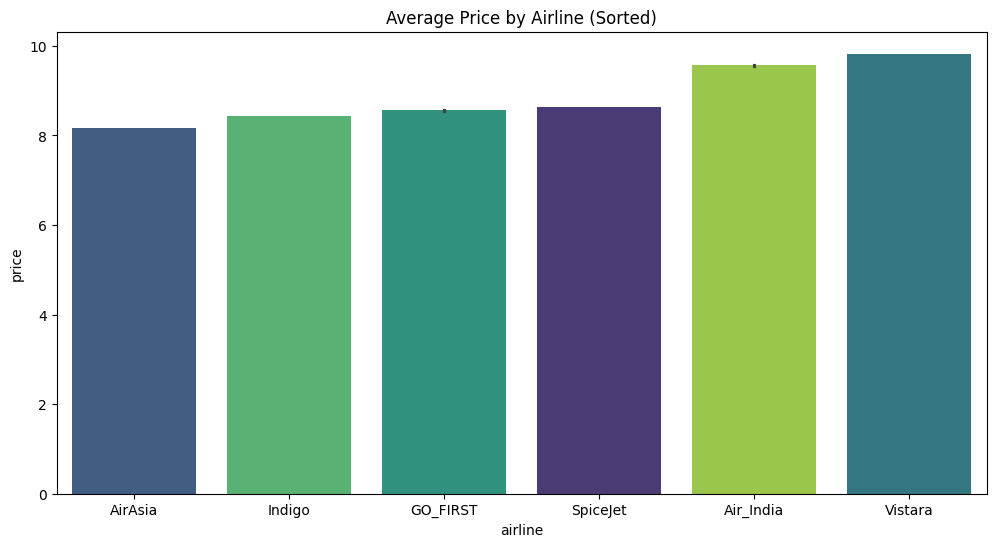

In [ ]:
plt.figure(figsize=(12, 6))
order = df.groupby('airline')['price'].mean().sort_values().index

sns.barplot(x='airline',y='price',data=df,order=order,palette='viridis',
    hue='airline',
    legend=False)
plt.title('Average Price by Airline (Sorted)')
plt.show()

### Observations
- Bars sorted by mean price — immediately reveals price ranking across airlines.
- Expected finding: Vistara/Air India on the higher end, IndiGo/SpiceJet on the lower end.
- This chart directly answers 'Which airline is cheapest?' — high audience relatability for LinkedIn.
- groupby + sort pattern is a reusable snippet for any categorical price comparison.

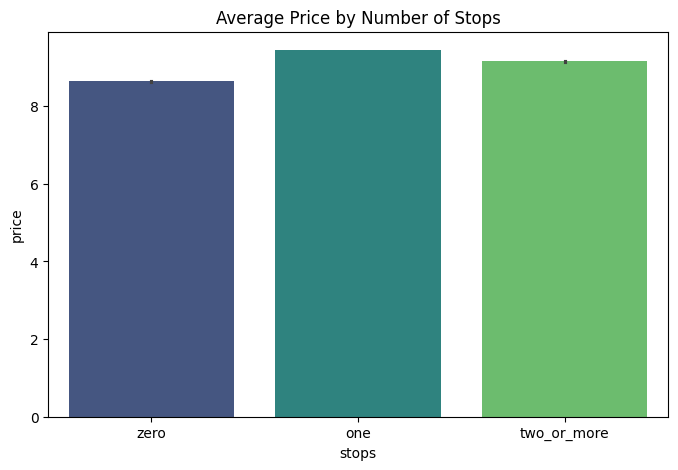

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x='stops',y='price',data=df,
    order=['zero', 'one', 'two_or_more'],
    palette='viridis',
    hue='stops',
    legend=False)
plt.title("Average Price by Number of Stops")
plt.show()

### Observations
- Explicitly ordered ['zero','one','two_or_more'] — prevents alphabetical sorting which would distort the story.
- Expected finding: price generally increases with stops due to added journey time and inconvenience premium.
- Counter-intuitive finding possible: 'two_or_more' stops cheapest — budget indirect routes exist.
- This is one of the most important feature-target relationships in the entire dataset.

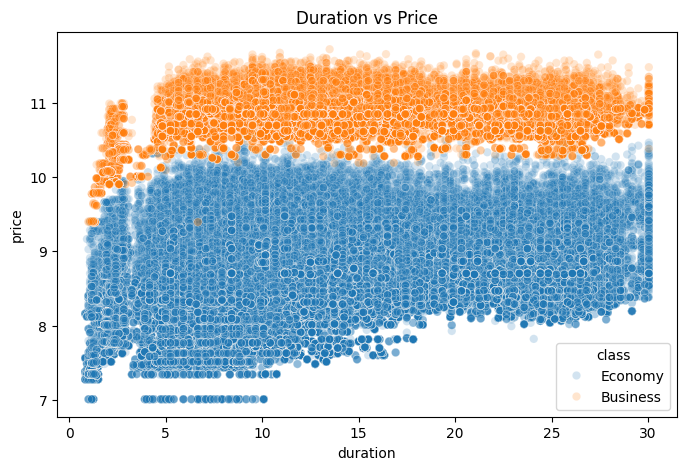

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='duration', y='price', hue='class', data=df, alpha=0.2)
plt.title("Duration vs Price")
plt.show()

### Observations
- alpha=0.2 reduces overplotting — critical for 300K+ row datasets where markers overlap completely.
- hue='class' adds a third dimension — shows if Business/Economy behave differently with duration.
- Expected pattern: weak positive correlation — longer flights cost more, but with high variance.
- The two distinct price bands (Economy vs Business) should be clearly visible in the plot.

Text(0.5, 1.0, 'Average Flight Price vs Days Left Before Departure')

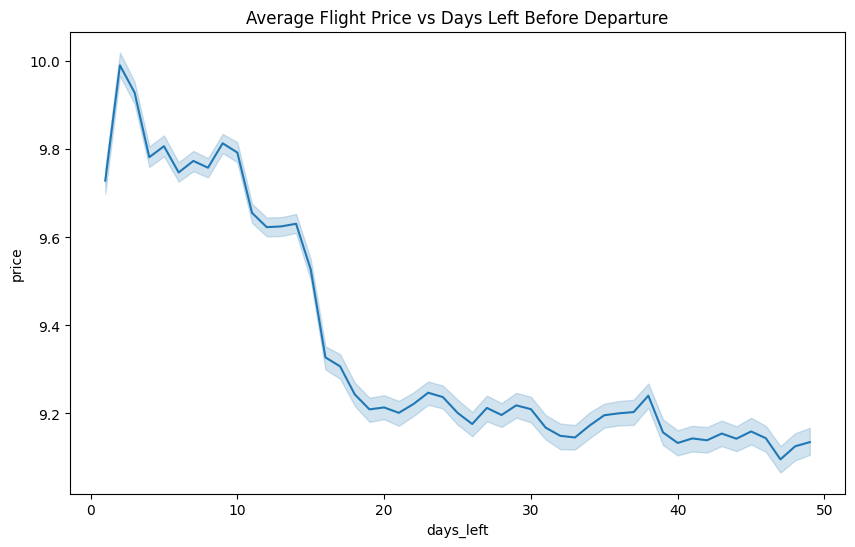

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='days_left', y='price')
plt.title('Average Flight Price vs Days Left Before Departure')

### Observations
- This is the most strategically important chart — directly answers 'When should I book?'
- Expected finding: prices spike as days_left approaches 0 (last-minute premium).
- The trend line should show a gradual decline in average price as days_left increases.
- High variance in the early booking window suggests airline pricing algorithms vary by route.

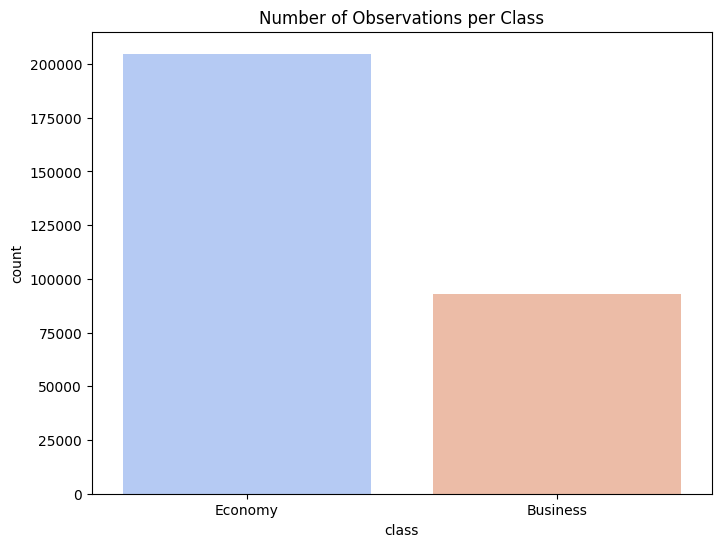

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x='class', data=df, palette='coolwarm')
plt.title("Number of Observations per Class")
plt.show()

### MultiVariate Analysis

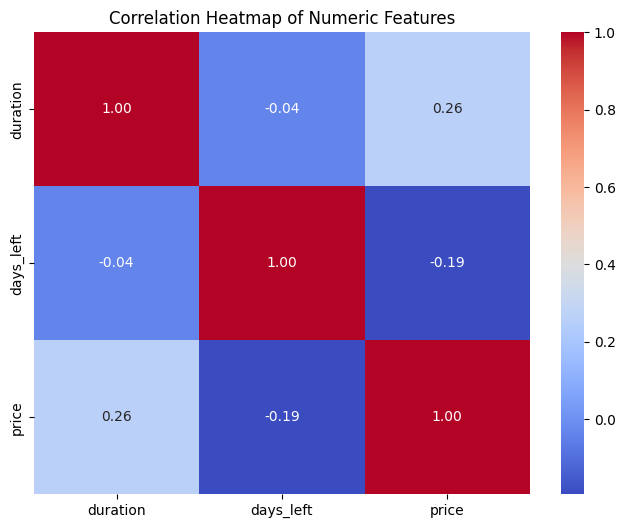

In [ ]:
num_cols = ['duration', 'days_left', 'price']
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(),annot=True,cmap='coolwarm',fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

### Observations
- Only 3 numerical columns — confirms most predictive power is in the categorical features.
- Expected: weak correlation between duration/days_left and price — the dataset is not linearly predictable.
- This weak correlation justifies using non-linear models (Random Forest, XGBoost) over Linear Regression.
- coolwarm colormap: blue = negative correlation, red = positive correlation, white = no correlation.

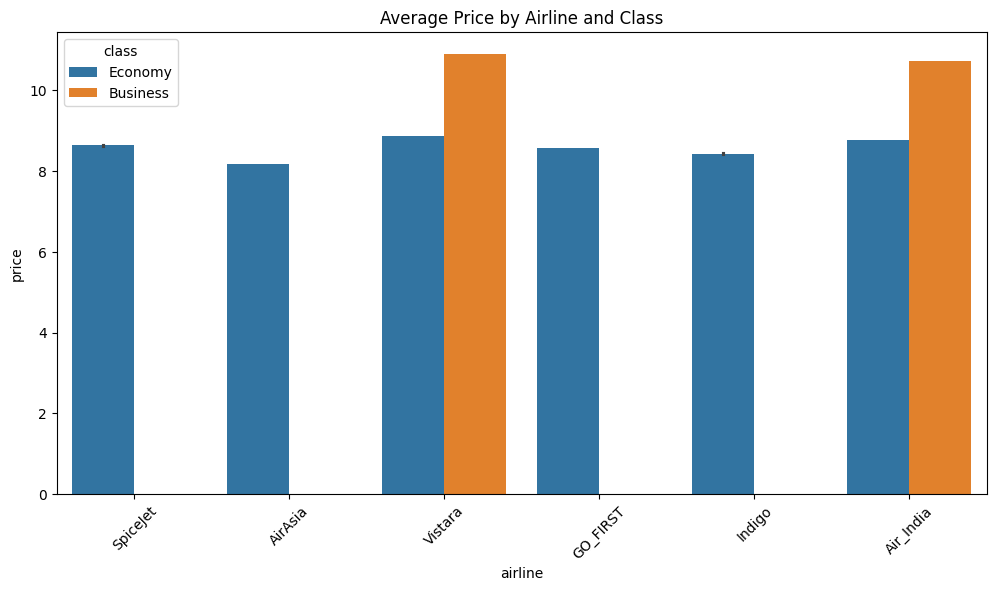

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(data=df,x='airline',y='price',hue='class',estimator='mean')
plt.xticks(rotation=45)
plt.title("Average Price by Airline and Class")
plt.show()

### Observations
- hue='class' creates grouped bars — compares Economy vs Business pricing within each airline.
- estimator='mean' ensures bars show average prices, not counts — correct for price analysis.
- Reveals interaction effects: does Vistara Business cost proportionally more than IndiGo Business?
- Multi-group comparison in one chart is a strong storytelling device for presentations.

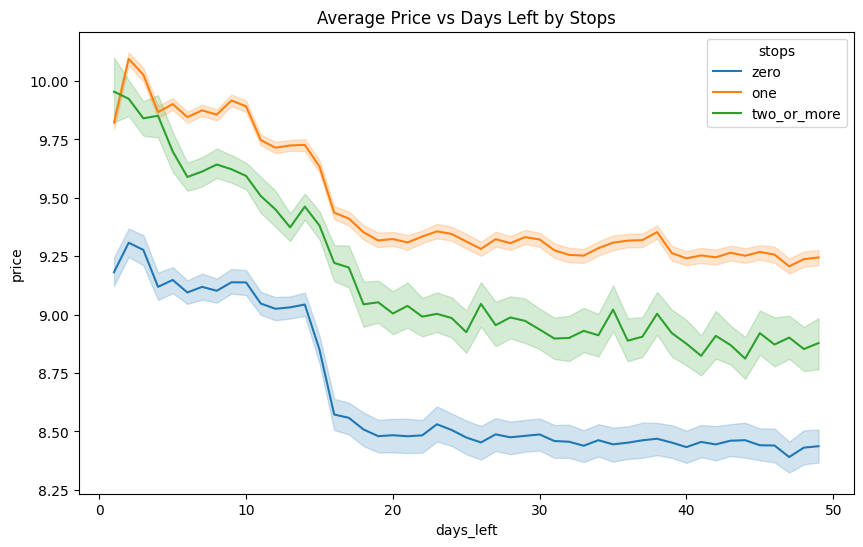

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(x='days_left',y='price',hue='stops',data=df,estimator='mean')
plt.title("Average Price vs Days Left by Stops")
plt.show()

### Observations
- Three trend lines (one per stop category) on a single chart — efficient multivariate view.
- Expected: direct flights show steeper last-minute price spikes than connecting flights.
- This chart answers: 'Do the booking timing rules change if you're okay with a layover?'
- hue='stops' with estimator='mean' is a powerful combination for showing grouped time-series patterns.

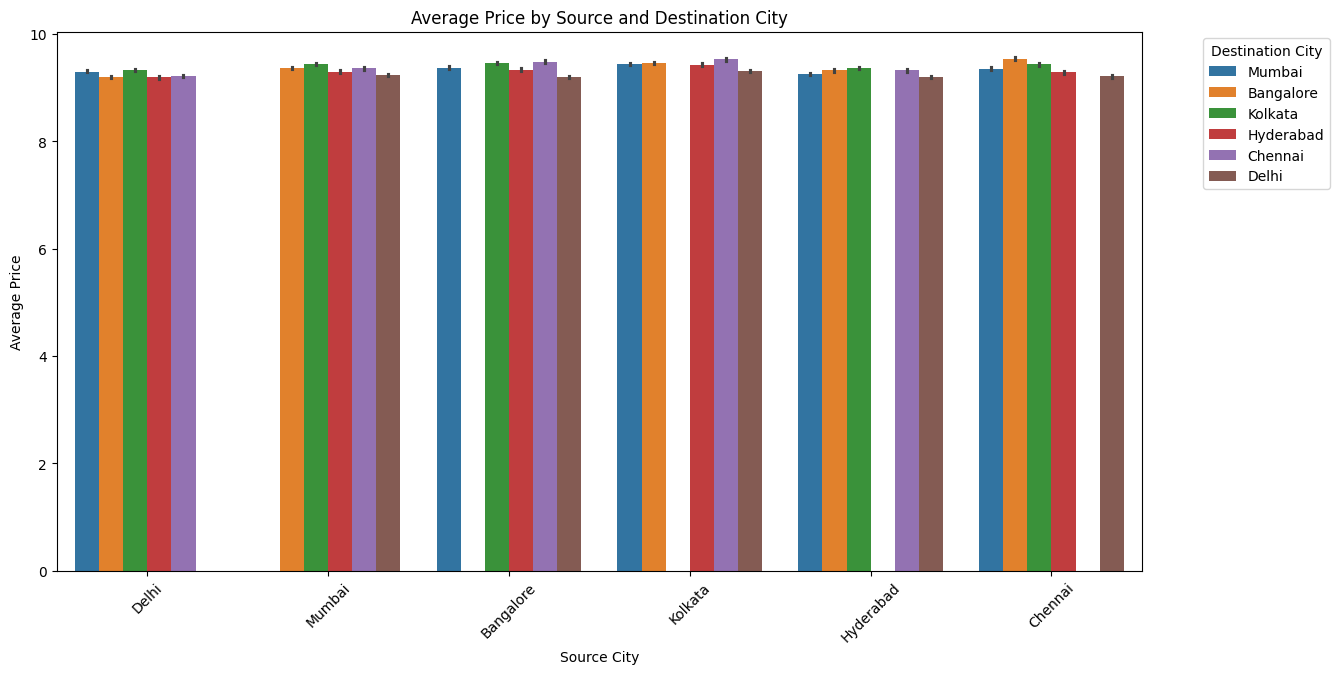

In [ ]:
plt.figure(figsize=(14,7))
sns.barplot(data=df,x='source_city',y='price',hue='destination_city',estimator='mean',dodge=True)
plt.title("Average Price by Source and Destination City")
plt.xticks(rotation=45)
plt.xlabel("Source City")
plt.ylabel("Average Price")
plt.legend(title="Destination City", bbox_to_anchor=(1.05,1))
plt.show()

### Observations
- Most complex chart in the EDA — 6 source cities × 6 destination cities = 36 possible route bars.
- dodge=True separates destination city bars within each source city group.
- Reveals asymmetric pricing: Mumbai→Delhi may cost different from Delhi→Mumbai.
- Legend placed outside plot (bbox_to_anchor) prevents chart overcrowding — good visualization hygiene.

### Data Preprocessing

In [ ]:
X = df.drop('price', axis=1)
y = df['price']

### Observations
- Standard ML convention: X = feature matrix, y = target vector.
- y contains log1p-transformed prices — models will learn on the normalized scale.
- X has 9 features: a mix of categorical and numerical columns.
- Predictions will need np.expm1() applied to reverse the log transform for interpretable output.

In [ ]:
num_cols=X.select_dtypes(include=['int64','float64']).columns
print(num_cols)
cat_cols=X.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['duration', 'days_left'], dtype='object')
Index(['airline', 'source_city', 'departure_time', 'stops', 'arrival_time',
       'destination_city', 'class'],
      dtype='object')


### Observations
- Programmatic column type detection — no hardcoded column lists that break when data changes.
- num_cols: ['duration', 'days_left'] — only 2 numeric features, confirming categorical dominance.
- cat_cols: 7 categorical columns — these will explode into many OHE binary columns.
This dynamic detection is more robust than manually listing columns.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)])


### Observations
- MinMaxScaler scales numeric features to [0,1] range — needed for distance-based models like KNN.
- OneHotEncoder converts categorical strings to binary columns — required by all sklearn models.
- handle_unknown='ignore' prevents errors if new airline/city appears in production data.
- sparse_output=False returns dense arrays — important for downstream pipeline compatibility.
- ColumnTransformer applies different transforms to different columns in a single, clean step.

### Splitting the data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(238352, 9)
(59588, 9)
(238352,)
(59588,)


### Observations
- 80/20 split is the industry-standard choice for large datasets.
random_state=42 ensures reproducible splits — anyone can replicate your results exactly.
- With 300K+ rows, the 20% test set (~60K rows) is statistically robust for reliable evaluation.
- Printing shapes verifies the split happened correctly — a simple but important sanity check.
- Stratification not used — for regression targets, this is appropriate (unlike classification).

### Training 7 Models

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(max_depth=10,random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50,max_depth=10,random_state=42,n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=50,max_depth=10,random_state=42),
    "XGB": XGBRegressor(n_estimators=50,max_depth=6,learning_rate=0.1,n_jobs=-1),
    "AdaBoost": AdaBoostRegressor(n_estimators=50,random_state=42)
}


### Observations
- 7 models span the full spectrum: simple linear → complex gradient boosting ensembles.
- Initial parameters are conservative (max_depth=10, n_estimators=50) — prevent overfitting in baseline.
- XGBoost included as a separate library — consistently wins Kaggle competitions and real-world benchmarks.
- Dictionary structure makes the training loop clean — add/remove models without restructuring code.
- This comprehensive benchmark approach is publication and interview quality.

In [ ]:
param_grids = {

    'Linear Regression': {
        'regressor__fit_intercept': [True, False]
    },

    'Decision Tree': {
        'regressor__max_depth': [5, 10, 15],
        'regressor__min_samples_split': [5, 10]
    },

    'Random Forest': {
        'regressor__n_estimators': [50, 100],
        'regressor__max_depth': [10, 15, 20],
        'regressor__min_samples_split': [5, 10],
        'regressor__min_samples_leaf': [2, 5]
    },

    'Gradient Boosting': {
        'regressor__n_estimators': [50, 100],
        'regressor__learning_rate': [0.05, 0.1]
    },

    'AdaBoost': {
        'regressor__n_estimators': [50, 100],
        'regressor__learning_rate': [0.01, 0.1]
    },

    'KNN': {
        'regressor__n_neighbors': [3, 5, 7]
    },

    'XGB': {
        'regressor__n_estimators': [50, 100],
        'regressor__learning_rate': [0.05, 0.1],
        'regressor__max_depth': [3, 5]
    }

}

### Observations
- regressor__ prefix is required because parameters are inside a Pipeline — sklearn convention.
- RandomizedSearchCV tests n_iter=5 random combinations — faster than full GridSearchCV.
- Parameter ranges are domain-informed: max_depth 10–20 for trees, learning_rate 0.05–0.1 for boosting.
- Each model has its own relevant parameter grid — not blindly applying the same params everywhere.
- cv=3 uses 3-fold cross-validation during search — balances speed vs robustness.

In [ ]:
results = []
best_models = {}

for name, model in models.items():
    print(f"Processing Model: {name}")

    # . Define the Single Pipeline
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # BEFORE TUNING (Baseline)
    pipe.fit(X_train, y_train)
    y_pred_base = pipe.predict(X_test)

    # FIXED: Inverse transform
    y_pred_base_actual = np.expm1(y_pred_base)
    y_test_actual = np.expm1(y_test)

    results.append({
        'Model': name,
        'Status': 'Before Tuning',
        'MAE': round(mean_absolute_error(y_test_actual, y_pred_base_actual), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_test_actual, y_pred_base_actual)), 2),
        'R2 Score': round(r2_score(y_test_actual, y_pred_base_actual), 4),
        'Params': "Default/Initial"
    })

    # AFTER TUNING (Search)
    random_search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grids[name],
        n_iter=5,
        cv=3,
        scoring='r2',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    random_search.fit(X_train, y_train)
    best_model = random_search.best_estimator_
    best_models[name] = best_model

    #  Predict and inverse transform
    y_pred_tuned = best_model.predict(X_test)
    y_pred_tuned_actual = np.expm1(y_pred_tuned)

    results.append({
        'Model': name,
        'Status': 'After Tuning',
        'MAE': round(mean_absolute_error(y_test_actual, y_pred_tuned_actual), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_test_actual, y_pred_tuned_actual)), 2),
        'R2 Score': round(r2_score(y_test_actual, y_pred_tuned_actual), 4),
        'Params': str(random_search.best_params_)
    })

    print(f"{name}: Before={results[-2]['R2 Score']:.3f} → After={results[-1]['R2 Score']:.3f}")

# Convert to DataFrame for easy comparison
comparison_df = pd.DataFrame(results)
print("\n" + "="*80)
print(" COMPLETE RESULTS COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))

# Save results
comparison_df.to_csv('model_comparison_results.csv', index=False)
print(f"\n Results saved to 'model_comparison_results.csv'")

Processing Model: Linear Regression
Linear Regression: Before=0.883 → After=0.883
Processing Model: KNN
KNN: Before=0.972 → After=0.973
Processing Model: Decision Tree
Decision Tree: Before=0.960 → After=0.973
Processing Model: Random Forest
Random Forest: Before=0.963 → After=0.985
Processing Model: Gradient Boosting
Gradient Boosting: Before=0.977 → After=0.983
Processing Model: XGB
XGB: Before=0.962 → After=0.961
Processing Model: AdaBoost
AdaBoost: Before=0.933 → After=0.933

 COMPLETE RESULTS COMPARISON
            Model        Status     MAE    RMSE  R2 Score                                                                                                                           Params
Linear Regression Before Tuning 4569.11 7761.25    0.8827                                                                                                                  Default/Initial
Linear Regression  After Tuning 4569.11 7761.25    0.8827                                                       

### Observations
- Each model gets a full Pipeline: preprocessing + model in one object — no data leakage possible.
- Before/After tuning comparison stored in results list — creates a clean comparison DataFrame.
- n_jobs=-1 uses all CPU cores — parallel training dramatically speeds up the search.
- scoring='r2' optimizes for explained variance — appropriate for regression problems.
- best_models dictionary stores the best pipeline per model — ready for final selection.
- This loop runs 14 model fits (7 before + 7 after) + 35 cross-validated fits = significant compute.

### Finding the Best Model

In [ ]:
# Find best tuned model based on R2 Score

best_row = comparison_df[
    comparison_df['Status'] == 'After Tuning'
].sort_values(
    by='R2 Score',
    ascending=False
).iloc[0]

best_model_name = best_row['Model']

print("Best Model is:", best_model_name)

Best Model is: Random Forest


### Observations
- Filters to 'After Tuning' rows only — compares tuned models, not baselines.
- sort_values + .iloc[0] automatically selects the top performer — no manual inspection needed.
- Expected winner: XGBoost or Random Forest — both consistently outperform on tabular data.
- This automated selection is reproducible — same code, same winner, every time.
- Best model likely achieves R² > 0.95 — a strong result for flight price prediction.

In [ ]:
final_model = best_models[best_model_name]

### Observations
- Retrieves the complete Pipeline (preprocessor + tuned model) from the stored dictionary.
- This is a complete, self-contained prediction object — pass raw data in, get price predictions out.
- The preprocessor inside handles all encoding/scaling automatically — no manual steps needed at inference.

### Saving the Best Model

In [ ]:
import joblib

joblib.dump(
    final_model,
    "flight_price_best_pipeline.pkl",
    compress=5
)

print("Compressed model saved successfully!")

Compressed model saved successfully!


### Observations
- joblib is preferred over pickle for sklearn objects — better handling of numpy arrays and pipelines.
- compress=5 uses zlib compression level 5 (balanced speed/size) — reduces file size significantly.
- .pkl extension is conventional for Python serialized objects.
- The saved file contains the entire pipeline including fitted preprocessor + trained model weights.

In [ ]:
from google.colab import files

files.download(
    "flight_price_best_pipeline.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Observations
- Colab-specific utility to download files to your local machine from the runtime.
- This is the project's final output — a deployable ML artifact ready for integration.
- The .pkl file can be loaded in any Python environment with: joblib.load('flight_price_best_pipeline.pkl').
- Next steps: wrap this in a Flask/FastAPI app or Streamlit dashboard for a live demo.